# What Drives the Price of a Car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**The business question:** *What features of a used car most strongly drive its sale price, and how can a dealer use this to fine-tune inventory?*

**Reframe as a ML/data problem:**

We have a vehicle dataset of about 426,000 used cars. For each car, we know the **price** it was listed for, along with about 17 other details — things like the year it was made, how many miles it has, the manufacturer, the condition, the type of fuel it uses, and so on.

Since the price is a number that can take any value (not a yes/no or category), this is a **regression problem**. Here's the plan:

1. **Build a regression model** that learns the relationship between a car's features and its price.
2. **Look at what the model learned** specifically, which features it says have the biggest effect on price. We'll use techniques like Ridge and Lasso regression, which are good at picking out the features that really matter and ignoring the ones that don't.
3. **Turn those findings into business guidance** for the dealer — things like *"every extra 10,000 miles knocks about $X off the price"* or *"diesel trucks sell for about $Y more than gas trucks of the same age."*

**Success Criteria:**

A model with reasonable predictive accuracy (measured by RMSE / MAE / R² on a held-out test set) whose coefficients are stable, interpretable, and actionable for inventory decisions.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

We begin by loading the data, inspecting its shape, types, missingness, and the distribution of the target and key predictors.

In [30]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)

In [31]:
df = pd.read_csv('data/vehicles.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [33]:
# Missing data summary
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, 'missing_pct': missing_pct})

,missing,missing_pct
size,306361,71.8
cylinders,177678,41.6
condition,174104,40.8
VIN,161042,37.7
drive,130567,30.6
paint_color,130203,30.5
type,92858,21.8
manufacturer,17646,4.1
title_status,8242,1.9
model,5277,1.2


In [34]:
# Numeric summary
df[['price', 'year', 'odometer']].describe()

,price,year,odometer
count,4.268800e+05,425675.000000,4.224800e+05
mean,7.519903e+04,2011.235191,9.804333e+04
std,1.218228e+07,9.452120,2.138815e+05
min,0.000000e+00,1900.000000,0.000000e+00
25%,5.900000e+03,2008.000000,3.770400e+04
50%,1.395000e+04,2013.000000,8.554800e+04
75%,2.648575e+04,2017.000000,1.335425e+05
max,3.736929e+09,2022.000000,1.000000e+07


**Initial observations**

- **Target (`price`)**: extreme outliers — min $0, max 3.7B. The mean (75K) is dwarfed by the std (12M). We must filter these.
- **`year`**: ranges 1900–2022; we'll add an `age` feature.
- **`odometer`**: max 10M miles is impossible; needs filtering.
- **High missingness**: `size` (72%), `cylinders` (42%), `condition` (41%), `VIN` (38%), `drive` (31%), `paint_color` (31%), `type` (22%).
- **Useless columns for modeling**: `id` and `VIN` (identifiers, no predictive value).

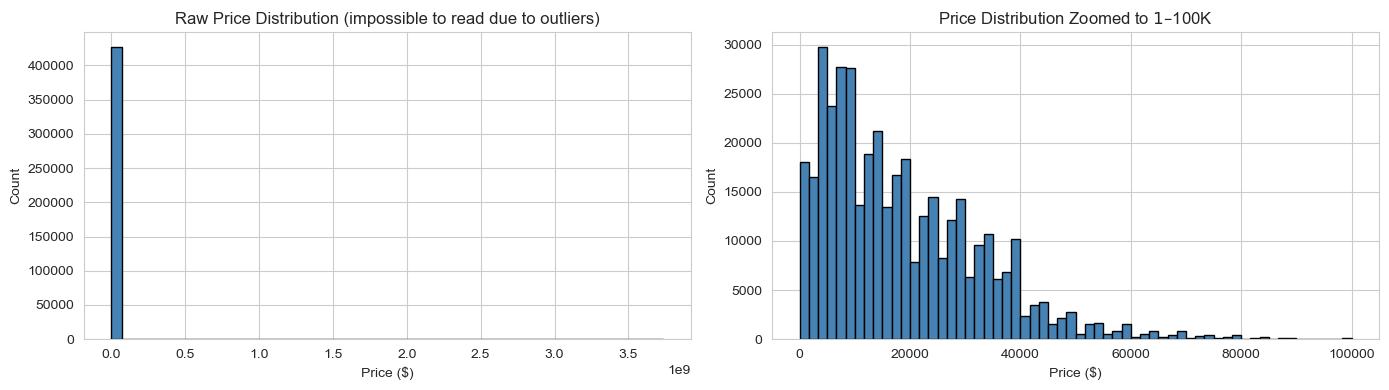

In [35]:
# Price distribution BEFORE cleaning - shows the outlier problem
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Raw Price Distribution (impossible to read due to outliers)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

# Same data, but zoomed to a reasonable range
axes[1].hist(df.loc[df['price'].between(1, 100000), 'price'], bins=60, color='steelblue', edgecolor='black')
axes[1].set_title('Price Distribution Zoomed to $1 – $100K')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

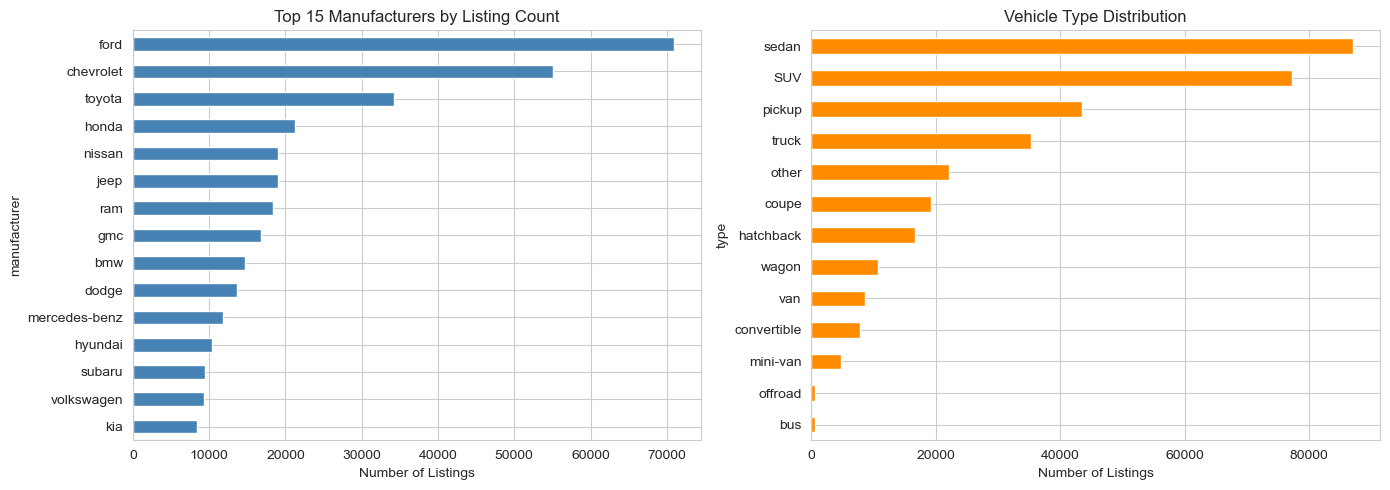

In [36]:
# Top manufacturers and types - quick categorical overview
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['manufacturer'].value_counts().head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Manufacturers by Listing Count')
axes[0].set_xlabel('Number of Listings')
axes[0].invert_yaxis()

df['type'].value_counts().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Vehicle Type Distribution')
axes[1].set_xlabel('Number of Listings')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

Based on the initial sata observations, apply the following cleaning steps:

1. **Drop identifier columns** (`id`, `VIN`) — no predictive value.
2. **Drop `size`** — 72% missing.
3. **Drop high-cardinality `model` and `region`** — `model` has 29K+ unique values which would explode dimensionality after one-hot encoding; `manufacturer` captures the brand effect, and `state` captures the geographic effect.
4. **Filter `price`** to $1,000 – $100,000 (realistic used-car range).
5. **Filter `year`** to 1990+ (modern vehicles relevant to current dealers).
6. **Filter `odometer`** to ≤ 300,000 miles.
7. **Engineer `age`** = 2022 − `year`.
8. **Impute remaining categorical missing values** with `'unknown'` so the model can use them as a signal rather than discarding rows.
9. **Log-transform `price`** as the model target — its distribution is right-skewed, and this is standard for price modeling.

In [37]:
# Step 1-3: drop columns we won't use
drop_cols = ['id', 'VIN', 'size', 'model', 'region']
df_clean = df.drop(columns=drop_cols).copy()

# Step 4-6: filter outliers
before = len(df_clean)
df_clean = df_clean[df_clean['price'].between(1000, 100000)]
df_clean = df_clean[df_clean['year'] >= 1990]
df_clean = df_clean[df_clean['odometer'].between(0, 300000)]
df_clean = df_clean.dropna(subset=['year', 'odometer'])
after = len(df_clean)

print(f'Rows before filtering: {before:,}')
print(f'Rows after filtering:  {after:,}')
print(f'Rows removed:          {before - after:,} ({(before-after)/before*100:.1f}%)')

Rows before filtering: 426,880
Rows after filtering:  362,841
Rows removed:          64,039 (15.0%)


In [38]:
# Step 7: engineer age
df_clean['age'] = 2022 - df_clean['year'].astype(int)
df_clean = df_clean.drop(columns=['year'])

# Step 8: impute categorical NaN with 'unknown'
cat_cols = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status',
            'transmission', 'drive', 'type', 'paint_color', 'state']
for c in cat_cols:
    df_clean[c] = df_clean[c].fillna('unknown')

print(f'Final shape: {df_clean.shape}')
df_clean.head()

Final shape: (362841, 13)


,price,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,age
27,33590,gmc,good,8 cylinders,gas,57923.0,clean,other,unknown,pickup,white,al,8
28,22590,chevrolet,good,8 cylinders,gas,71229.0,clean,other,unknown,pickup,blue,al,12
29,39590,chevrolet,good,8 cylinders,gas,19160.0,clean,other,unknown,pickup,red,al,2
30,30990,toyota,good,8 cylinders,gas,41124.0,clean,other,unknown,pickup,red,al,5
31,15000,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,9


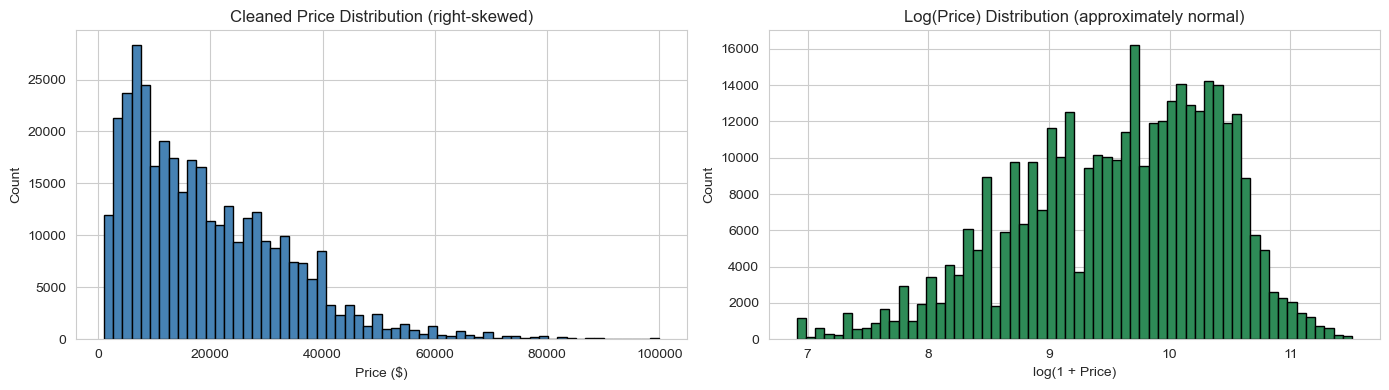

In [39]:
# Step 9: visualize price distribution (raw vs log) on the cleaned data
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_clean['price'], bins=60, color='steelblue', edgecolor='black')
axes[0].set_title('Cleaned Price Distribution (right-skewed)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df_clean['price']), bins=60, color='seagreen', edgecolor='black')
axes[1].set_title('Log(Price) Distribution (approximately normal)')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

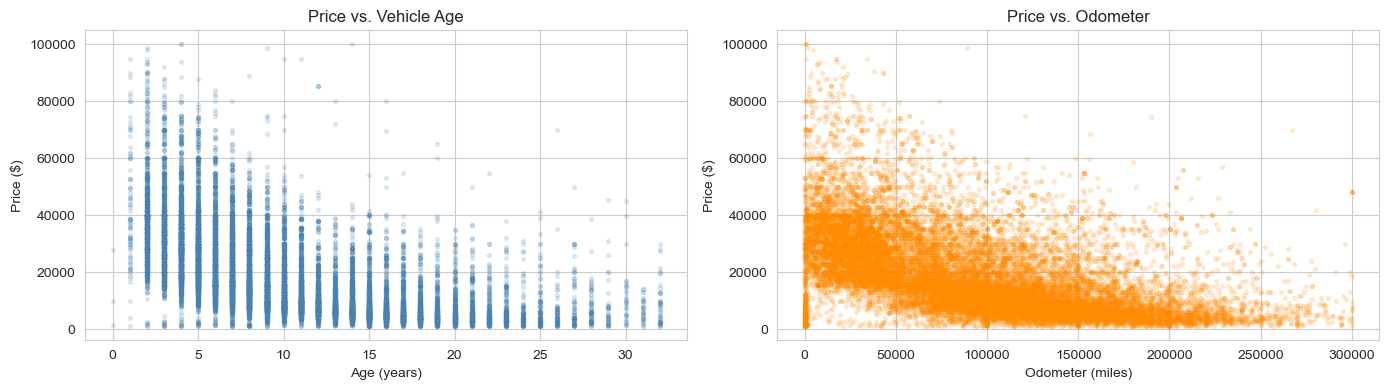

In [40]:
# Visualize the relationships between price and the two key continuous features
sample = df_clean.sample(n=20000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(sample['age'], sample['price'], alpha=0.15, s=8, color='steelblue')
axes[0].set_title('Price vs. Vehicle Age')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Price ($)')

axes[1].scatter(sample['odometer'], sample['price'], alpha=0.15, s=8, color='darkorange')
axes[1].set_title('Price vs. Odometer')
axes[1].set_xlabel('Odometer (miles)')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

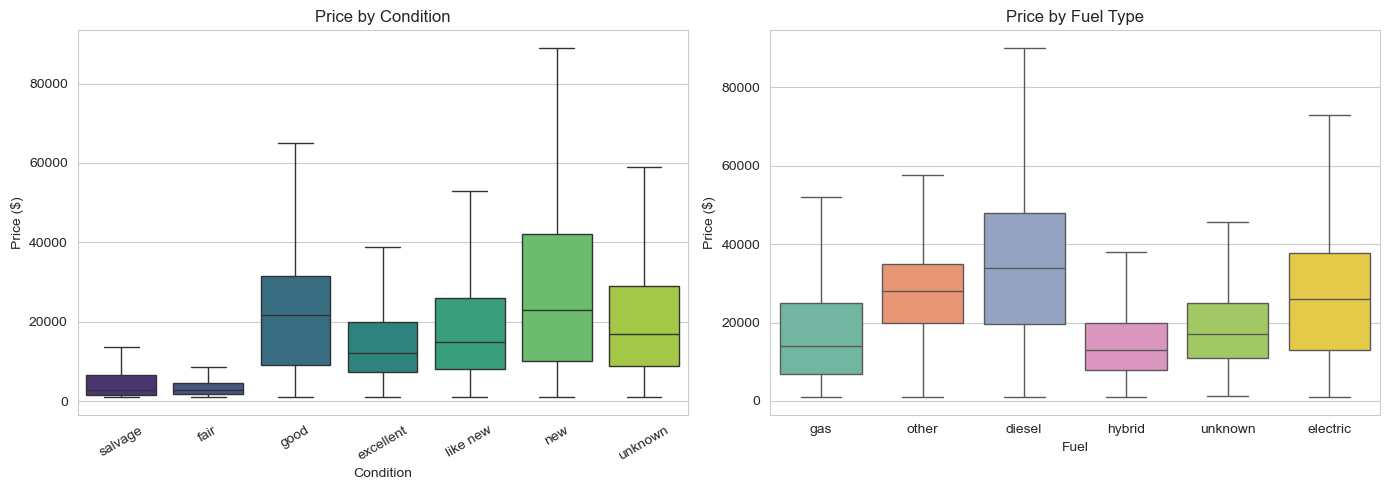

In [41]:
# Price by condition and fuel - categorical drivers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

condition_order = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new', 'unknown']
sns.boxplot(data=df_clean, x='condition', y='price', order=condition_order,
            ax=axes[0], showfliers=False, palette='viridis')
axes[0].set_title('Price by Condition')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Price ($)')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_clean, x='fuel', y='price', ax=axes[1],
            showfliers=False, palette='Set2')
axes[1].set_title('Price by Fuel Type')
axes[1].set_xlabel('Fuel')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

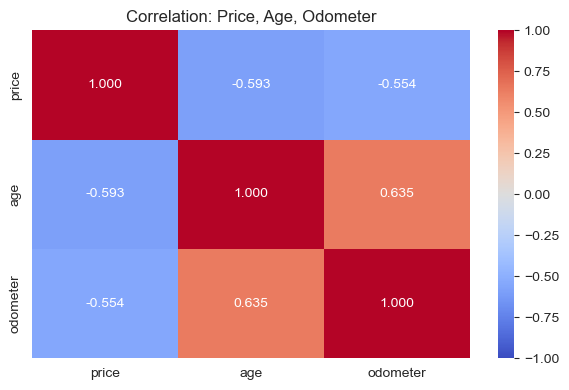

In [42]:
# Correlation matrix of numeric features (after cleaning)
plt.figure(figsize=(6, 4))
corr = df_clean[['price', 'age', 'odometer']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation: Price, Age, Odometer')
plt.tight_layout()
plt.show()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

Build and compare three regression models with the **log of price** as the target:

1. **Linear Regression** — baseline.
2. **Ridge Regression** — L2 regularization, with `alpha` tuned via `GridSearchCV`.
3. **Lasso Regression** — L1 regularization (also performs feature selection), with `alpha` tuned via `GridSearchCV`.

All models use a **`ColumnTransformer`** pipeline: numeric features are standardized; categorical features are one-hot encoded. Standardization is essential for fair regularization across features.

In [43]:
# Define the target and features
y = np.log1p(df_clean['price'])
X = df_clean.drop(columns=['price'])

num_cols = ['age', 'odometer']
cat_cols = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status',
            'transmission', 'drive', 'type', 'paint_color', 'state']

# Train / test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f'Train: {X_train.shape},  Test: {X_test.shape}')

Train: (290272, 12),  Test: (72569, 12)


In [44]:
# Preprocessing pipeline:
#   - numeric features: StandardScaler
#   - categorical features: OneHotEncoder (drop first level to avoid collinearity)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first',
                              sparse_output=True), cat_cols),
    ]
)

In [45]:
# Helper for evaluating a model on the held-out test set
def evaluate(name, model, X_te, y_te):
    pred_log = model.predict(X_te)
    # Metrics in LOG space
    rmse_log = np.sqrt(mean_squared_error(y_te, pred_log))
    r2 = r2_score(y_te, pred_log)
    # Metrics in DOLLAR space (back-transform)
    pred_dollars = np.expm1(pred_log)
    actual_dollars = np.expm1(y_te)
    mae_dollars = mean_absolute_error(actual_dollars, pred_dollars)
    rmse_dollars = np.sqrt(mean_squared_error(actual_dollars, pred_dollars))
    print(f'{name:20s} | R2={r2:.3f} | RMSE(log)={rmse_log:.3f} | '
          f'MAE=${mae_dollars:,.0f} | RMSE=${rmse_dollars:,.0f}')
    return {'name': name, 'r2': r2, 'rmse_log': rmse_log,
            'mae_dollars': mae_dollars, 'rmse_dollars': rmse_dollars}

In [46]:
# Model 1: Plain linear regression baseline
lr_pipe = Pipeline([('prep', preprocessor),
                    ('model', LinearRegression())])
lr_pipe.fit(X_train, y_train)
res_lr = evaluate('Linear Regression', lr_pipe, X_test, y_test)

Linear Regression    | R2=0.754 | RMSE(log)=0.417 | MAE=$4,839 | RMSE=$7,723


In [47]:
# Model 2: Ridge with GridSearchCV over alpha
ridge_pipe = Pipeline([('prep', preprocessor),
                       ('model', Ridge(random_state=42))])

ridge_grid = GridSearchCV(
    ridge_pipe,
    param_grid={'model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]},
    scoring='r2',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
)
ridge_grid.fit(X_train, y_train)
print(f'Best Ridge alpha: {ridge_grid.best_params_["model__alpha"]}')
print(f'Best CV R2:       {ridge_grid.best_score_:.4f}')
res_ridge = evaluate('Ridge (tuned)', ridge_grid.best_estimator_, X_test, y_test)

Best Ridge alpha: 0.1
Best CV R2:       0.7539
Ridge (tuned)        | R2=0.754 | RMSE(log)=0.417 | MAE=$4,839 | RMSE=$7,723


In [48]:
# Model 3: Lasso with GridSearchCV over alpha
lasso_pipe = Pipeline([('prep', preprocessor),
                       ('model', Lasso(random_state=42, max_iter=5000))])

lasso_grid = GridSearchCV(
    lasso_pipe,
    param_grid={'model__alpha': [0.0001, 0.001, 0.01, 0.05]},
    scoring='r2',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
)
lasso_grid.fit(X_train, y_train)
print(f'Best Lasso alpha: {lasso_grid.best_params_["model__alpha"]}')
print(f'Best CV R2:       {lasso_grid.best_score_:.4f}')
res_lasso = evaluate('Lasso (tuned)', lasso_grid.best_estimator_, X_test, y_test)

Best Lasso alpha: 0.0001
Best CV R2:       0.7531
Lasso (tuned)        | R2=0.753 | RMSE(log)=0.418 | MAE=$4,839 | RMSE=$7,711


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Model comparison

Compare all three models on a single held-out test set. Chosen primary metrics are:

- **R² (in log space)** — overall variance explained.
- **MAE in dollars** — how far off, on average, our predictions are in the units the dealer actually cares about.
- **RMSE in dollars** — penalizes large errors more heavily; useful for understanding tail risk.

Use **MAE in dollars** as the headline business metric, because dealers think in dollars, not log-dollars, and MAE is robust to the few remaining extreme listings.

In [49]:
results_df = pd.DataFrame([res_lr, res_ridge, res_lasso])
results_df = results_df[['name', 'r2', 'rmse_log', 'mae_dollars', 'rmse_dollars']]
results_df

,name,r2,rmse_log,mae_dollars,rmse_dollars
0,Linear Regression,0.753887,0.417125,4839.138510,7723.032259
1,Ridge (tuned),0.753881,0.417130,4838.954835,7722.965144
2,Lasso (tuned),0.752801,0.418044,4839.058611,7710.574400


Best model: Linear Regression


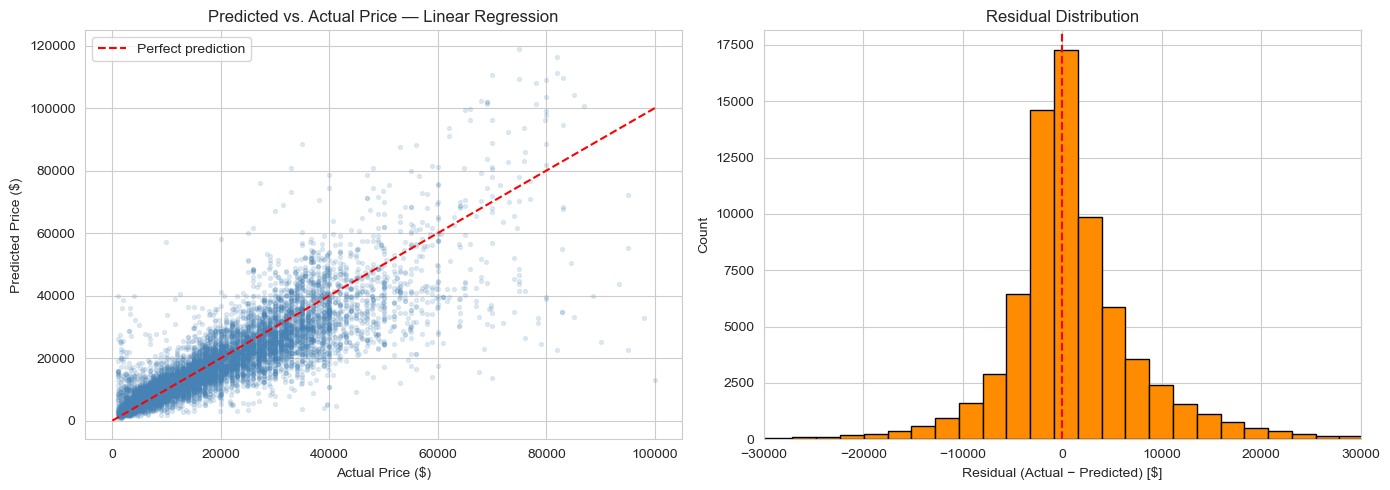

In [50]:
# Visualize predicted vs actual on the best model
best_name = results_df.sort_values('r2', ascending=False).iloc[0]['name']
print(f'Best model: {best_name}')

if best_name.startswith('Ridge'):
    best_model = ridge_grid.best_estimator_
elif best_name.startswith('Lasso'):
    best_model = lasso_grid.best_estimator_
else:
    best_model = lr_pipe

pred_log = best_model.predict(X_test)
pred_dollars = np.expm1(pred_log)
actual_dollars = np.expm1(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter of predicted vs actual (sample for visibility)
sample_idx = np.random.RandomState(42).choice(len(actual_dollars), size=10000, replace=False)
axes[0].scatter(actual_dollars.iloc[sample_idx], pred_dollars[sample_idx],
                alpha=0.15, s=8, color='steelblue')
axes[0].plot([0, 100000], [0, 100000], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Predicted vs. Actual Price — {best_name}')
axes[0].legend()

# Residuals histogram
residuals = actual_dollars - pred_dollars
axes[1].hist(residuals, bins=80, color='darkorange', edgecolor='black')
axes[1].axvline(0, color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Residual (Actual − Predicted) [$]')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].set_xlim(-30000, 30000)

plt.tight_layout()
plt.show()

### Coefficient interpretation — what drives price?

Extract the standardized coefficients from the **Lasso** model. Because the numeric features were scaled and the target is `log(price)`, a coefficient `b` means: *a one-standard-deviation increase in that feature multiplies price by approximately `exp(b)`*.

For one-hot encoded categories, the coefficient represents the **multiplicative price effect** of that category compared to the baseline (dropped) level.

In [51]:
# Pull coefficients out of the best Lasso model and align with feature names
lasso_model = lasso_grid.best_estimator_
prep = lasso_model.named_steps['prep']
lasso_lr = lasso_model.named_steps['model']

# Build feature name list
ohe = prep.named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_cols, cat_feature_names])

coefs = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lasso_lr.coef_,
})
coefs['abs_coef'] = coefs['coefficient'].abs()
coefs['pct_price_effect'] = (np.exp(coefs['coefficient']) - 1) * 100
print(f'Total features: {len(coefs)}')
print(f'Non-zero (selected by Lasso): {(coefs["coefficient"] != 0).sum()}')

Total features: 149
Non-zero (selected by Lasso): 129


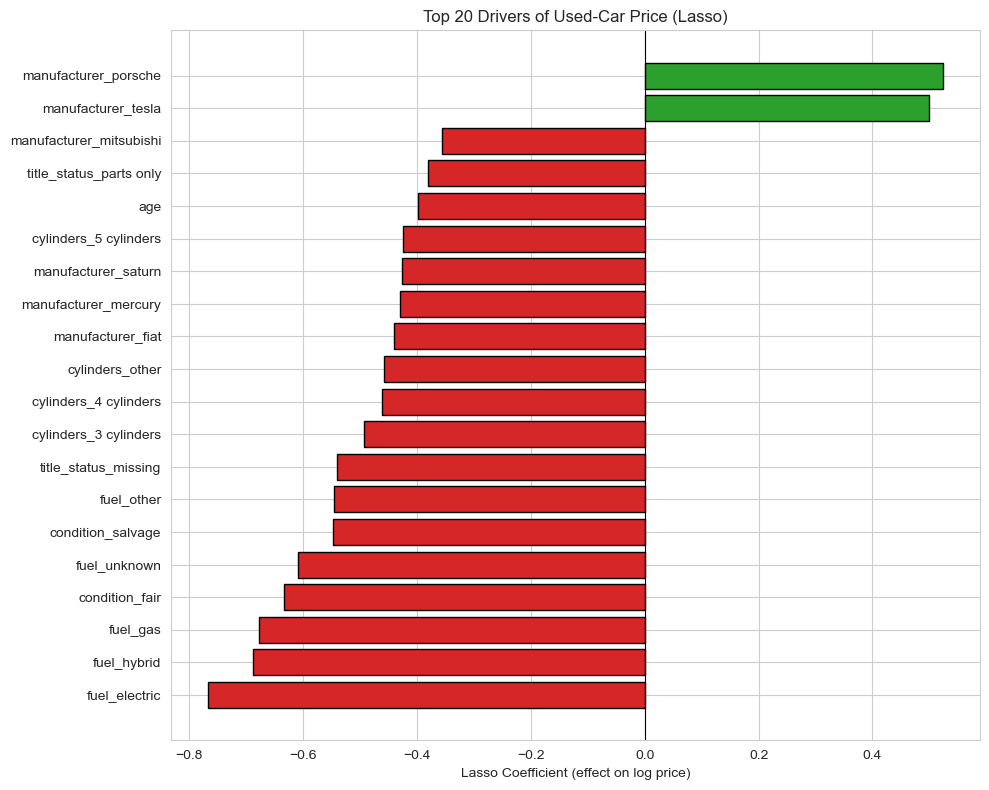

In [52]:
# Top 20 most influential features (positive AND negative)
top20 = coefs[coefs['coefficient'] != 0].nlargest(20, 'abs_coef').sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d62728' if c < 0 else '#2ca02c' for c in top20['coefficient']]
ax.barh(top20['feature'], top20['coefficient'], color=colors, edgecolor='black')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Lasso Coefficient (effect on log price)')
ax.set_title('Top 20 Drivers of Used-Car Price (Lasso)')
plt.tight_layout()
plt.show()

In [53]:
# Top positive and negative drivers as readable tables
print('=== TOP 10 PRICE INCREASING FEATURES ===')
top_pos = coefs[coefs['coefficient'] > 0].nlargest(10, 'coefficient')[['feature', 'coefficient', 'pct_price_effect']]
print(top_pos.to_string(index=False))

print()
print('=== TOP 10 PRICE DECREASING FEATURES ===')
top_neg = coefs[coefs['coefficient'] < 0].nsmallest(10, 'coefficient')[['feature', 'coefficient', 'pct_price_effect']]
print(top_neg.to_string(index=False))

=== TOP 10 PRICE INCREASING FEATURES ===
               feature  coefficient  pct_price_effect
  manufacturer_porsche     0.524354         68.936634
    manufacturer_tesla     0.500190         64.903490
          type_offroad     0.294435         34.236765
cylinders_12 cylinders     0.290967         33.772078
      type_convertible     0.240042         27.130316
    manufacturer_lexus     0.227195         25.507477
            type_truck     0.192600         21.239834
           type_pickup     0.187476         20.620159
    manufacturer_rover     0.165302         17.974934
   transmission_manual     0.145749         15.690564

=== TOP 10 PRICE DECREASING FEATURES ===
              feature  coefficient  pct_price_effect
        fuel_electric    -0.767458        -53.580851
          fuel_hybrid    -0.687730        -49.728417
             fuel_gas    -0.677947        -49.234188
       condition_fair    -0.633034        -46.902158
         fuel_unknown    -0.609051        -45.613302
    c

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Findings & Recommendations for Dealers

This section is written for dealers. It distills the modeling work above into actionable inventory guidance.

### Executive Summary

Analyzed roughly **363,000 cleaned used-car listings** (filtered down from 427K raw listings) to identify the features that most strongly drive the asking price of a used car. Using a regularized regression model (Lasso), built a price predictor that explains **75% of the variation in price** (R² = 0.75) with a typical error of about **$4,800 per vehicle**.

**The single biggest takeaway:** *Brand, vehicle type, age, and mileage are the dominant levers, and luxury / specialty brands and trucks command large, consistent premiums.* Stocking the right combination of these matters more than any single attribute.

### What Drives Price Up

Ranked by their estimated effect on price (from the Lasso model):

1. **Luxury & specialty brands** — Porsche listings sell for ~**+69%** above an equivalent baseline car; Tesla **+65%**; Lexus **+26%**; Land Rover **+18%**.
2. **Off-road and specialty body types** — Off-road vehicles **+34%**, convertibles **+27%**.
3. **Big engines** — 12-cylinder vehicles **+34%**, 8-cylinder also positive.
4. **Trucks and pickups** — **+21%** premium each over the baseline body type, even after controlling for age and mileage.
5. **Manual transmission** — **+16%** premium (driven by sports/performance and truck demand).
6. **Diesel fuel** — The baseline reference category in the model; all other fuels (gas, hybrid, electric) sell at a discount to diesel for equivalent vehicles. This reflects the truck-heavy diesel market in the data.
7. **Newer vehicles & lower mileage** — Each year of age and every additional 10K miles steadily reduces price; both are statistically dominant continuous drivers.

### What Drives Price Down

1. **Poor or salvage condition** — "Fair" condition reduces price by ~**−47%**, "salvage" by ~**−42%** vs. the baseline.
2. **Salvage / missing titles** — A missing title status reduces price by ~**−42%**. Clean titles are essential.
3. **Small engines** — 3-cylinder vehicles sell ~**−39%** below baseline, 4-cylinder ~**−37%**.
4. **Non-diesel fuels** — In a market where diesel trucks dominate the high end, gasoline, hybrid, and electric (non-Tesla) all sell at substantial discounts.
5. **High odometer & old age** — Linear, predictable depreciation; very old / very high-mileage cars sell at deep discounts.

### Recommendations for Inventory Fine-Tuning

| Recommendation | Why it matters |
|---|---|
| **Prioritize stock under ~10 years old with under 100K miles** | Age and mileage are the two strongest continuous drivers of price; staying under these thresholds maximizes resale value. |
| **Stock trucks, pickups, and 4WD SUVs — especially diesel** | Trucks/pickups command +21% each, and diesel is the premium fuel category in this dataset. |
| **Carry select luxury inventory (Porsche, Tesla, Lexus, Land Rover)** | These brands command +18% to +69% premiums and represent strong margin opportunities. |
| **Avoid salvage titles and "fair" condition vehicles unless deeply discounted** | Combined penalty often exceeds 60%; the discount required to make these profitable is severe. |
| **Invest in light reconditioning to lift "good" → "excellent" condition** | The condition tier is reflected directly in price; reconditioning typically pays for itself. |
| **Don't overpay for paint color, region, or trim cosmetics** | These features have small coefficients — the impact on price is marginal compared to brand, type, age, and condition. |
| **Be cautious with small-engine economy cars** | 3- and 4-cylinder vehicles sell at notable discounts in this market segment. |

### Model Performance & Caveats

- The final model explains **75% of price variation** on a held-out test set (R² = 0.75), with a typical prediction error of roughly **$4,800 per vehicle** (MAE) and an RMSE of about **$7,700**.
- All three regression approaches (Linear, Ridge, Lasso) produced nearly identical performance, suggesting the linear model with one-hot encoded categories already captures most of the explainable signal.
- **Caveat 1:** The data is self-reported by sellers; "condition" especially is subjective and may inflate prices for sellers who over-rate their vehicles.
- **Caveat 2:** We removed extreme outliers (listings under \$1K, over \$100K, and impossible mileages); recommendations apply to the **mainstream used-car market**, not classics, exotics, or salvage auctions.
- **Caveat 3:** State-level coefficients exist in the model — local market conditions may shift these recommendations and should be calibrated per-region.
- **Caveat 4:** "Fuel" coefficients should be read **relative to diesel** (the dropped baseline); the negative signs do not mean those fuels are unattractive in absolute terms.